In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d szrlee/stock-time-series-20050101-to-20171231


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/szrlee/stock-time-series-20050101-to-20171231
License(s): CC0-1.0
  0% 0.00/3.03M [00:00<?, ?B/s]
100% 3.03M/3.03M [00:00<00:00, 87.4MB/s]


In [ ]:
!unzip -q /content/stock-time-series-20050101-to-20171231.zip

### And now we get to the code...
I will use LSTMs for predicting the price of stocks of IBM for the year 2017

In [ ]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error

In [ ]:
# Some functions to help out with
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real IBM Stock Price')
    plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

In [ ]:
# First, we get the data
dataset = pd.read_csv('/content/IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [ ]:
dataset[:'2016']

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM
...,...,...,...,...,...,...
2016-12-23,167.00,167.49,166.45,166.71,1701228,IBM
2016-12-27,166.98,167.98,166.85,167.14,1397455,IBM
2016-12-28,167.29,167.74,166.00,166.19,1757500,IBM


In [ ]:
# Checking for missing values
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

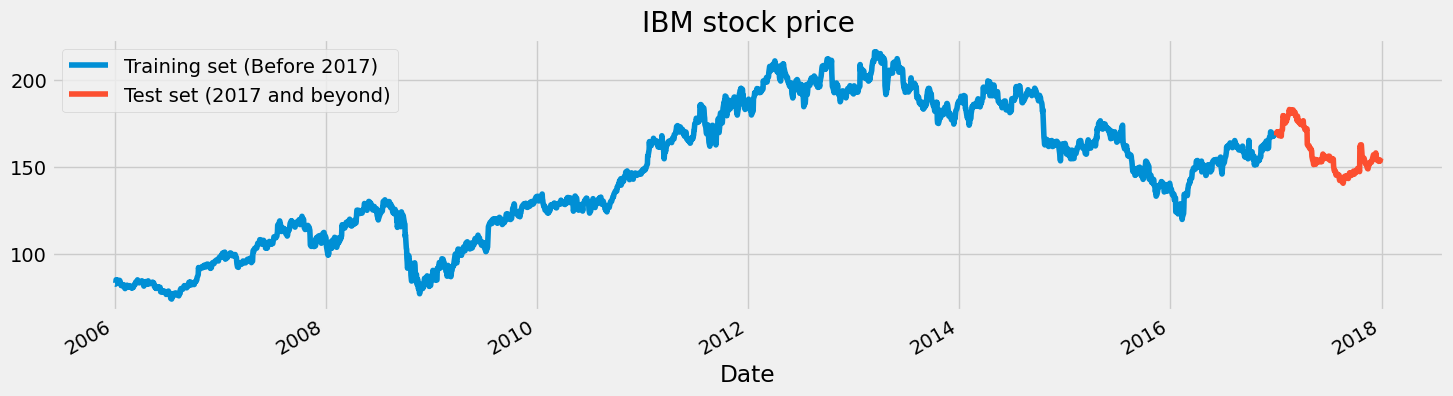

In [ ]:
# We have chosen 'High' attribute for prices. Let's see what it looks like
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [ ]:
# Scaling the training set
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
# Since LSTMs store long term memory state, we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements
X_train = []
y_train = []
for i in range(60,2769):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
# Reshaping X_train for efficient modelling
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

In [ ]:
# The LSTM architecture
regressor = Sequential()
# First LSTM layer with Dropout regularisation
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))
# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Third LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Fourth LSTM layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
# The output layer
regressor.add(Dense(units=1))

# Compiling the RNN
regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
# Fitting to the training set
regressor.fit(X_train,y_train,epochs=20,batch_size=32)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 0.0432
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - loss: 0.0116
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - loss: 0.0093
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0079
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 0.0078
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0049
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0059
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 0.0048
Epoch 9/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 0.0045
Epoch 10/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0044
Epoch 11/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0037
Epoch 12/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0038
Epoch 13/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0036
Epoch 14/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0034
Epoch 15/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0

In [ ]:
# Now to get the test set ready in a similar way as the training set.
# The following has been done so forst 60 entires of test set have 60 previous values which is impossible to get unless we take the whole
# 'High' attribute data for processing
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

In [ ]:
# Preparing X_test and predicting the prices
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


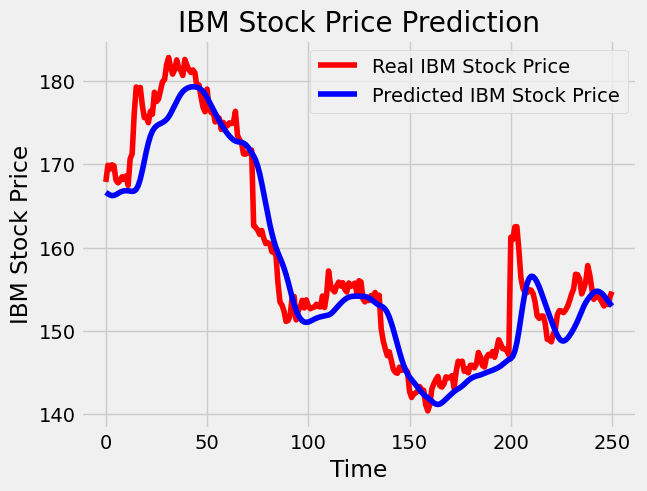

In [ ]:
# Visualizing the results for LSTM
plot_predictions(test_set,predicted_stock_price)

In [ ]:
# Evaluating our model
return_rmse(test_set,predicted_stock_price)

The root mean squared error is 3.689536128224543.


In [ ]:
# The GRU architecture
regressorGRU = Sequential()
# First GRU layer with Dropout regularisation
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Second GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Third GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Fourth GRU layer
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# The output layer
regressorGRU.add(Dense(units=1))
# Compiling the RNN
regressorGRU.compile(optimizer='rmsprop',loss='mean_squared_error')
# Fitting to the training set
regressorGRU.fit(X_train,y_train,epochs=20,batch_size=150)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - loss: 0.0810
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - loss: 0.0189
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - loss: 0.0100
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - loss: 0.0121
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - loss: 0.0092
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - loss: 0.0069
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - loss: 0.0089
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - loss: 0.0074
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - loss: 0.0066
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - loss: 0.0073
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - loss: 0.0067
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - loss: 0.0062
Epoch 13/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - loss: 0.0059
Epoch 14/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - loss: 0.0077
Epoch 15/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - loss: 0.0060


In [ ]:
# Preparing X_test and predicting the prices
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step


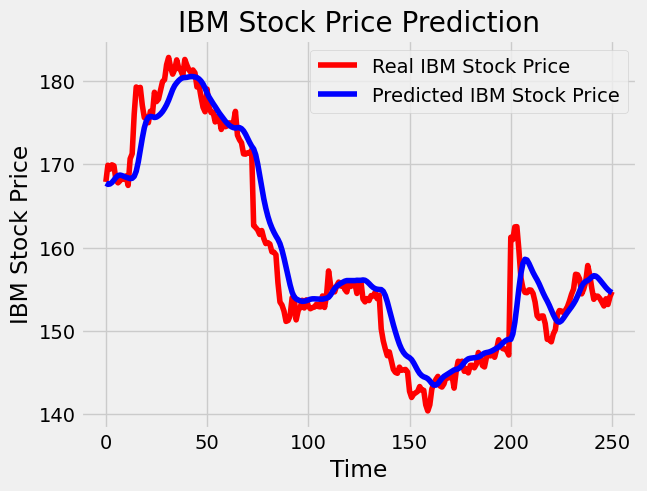

In [ ]:
# Visualizing the results for GRU
plot_predictions(test_set,GRU_predicted_stock_price)

In [ ]:
# Evaluating GRU
return_rmse(test_set,GRU_predicted_stock_price)

The root mean squared error is 3.1199179978407585.
